## 1. Dataset Overview

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
from database.connection import engine
from sqlalchemy import text
import pandas as pd

query = text("SELECT * FROM projects_raw")
df = pd.read_sql_query(query, engine)

In [3]:
filas, columnas = df.shape
print(f"Columnas: {columnas} --- Filas: {filas}")

Columnas: 13 --- Filas: 4722


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4722 entries, 0 to 4721
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           4722 non-null   int64         
 1   title        4722 non-null   str           
 2   description  4722 non-null   str           
 3   budget_min   4696 non-null   float64       
 4   budget_max   4589 non-null   float64       
 5   budget_type  4722 non-null   str           
 6   skills       4722 non-null   object        
 7   category     4722 non-null   str           
 8   subcategory  4722 non-null   str           
 9   project_url  4722 non-null   str           
 10  platform     4722 non-null   str           
 11  currency     4722 non-null   str           
 12  created_at   4722 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), object(1), str(8)
memory usage: 479.7+ KB


In [5]:
type(df["skills"].iloc[0])

list

In [6]:
print(f"NULLS 'budget_min': {((df['budget_min'].isna().sum() / df.shape[0]) * 100):.2f}%")
print(f"NULLS 'budget_max': {((df['budget_max'].isna().sum() / df.shape[0]) * 100):.2f}%")

NULLS 'budget_min': 0.55%
NULLS 'budget_max': 2.82%


In [7]:
print(df.loc[df['platform'] == 'Workana'].shape[0])
print(df.loc[df['platform'] == 'Freelancer'].shape[0])

350
4372


In [8]:
df.describe()

,id,budget_min,budget_max,created_at
count,4722.000000,4.696000e+03,4.589000e+03,4722
mean,2361.500000,5.334954e+03,1.309124e+04,2026-07-25 07:37:02.107949
min,1.000000,2.000000e+00,4.000000e+00,2026-07-25 07:37:02.107950
25%,1181.250000,3.000000e+01,1.600000e+02,2026-07-25 07:37:02.107950
50%,2361.500000,2.500000e+02,7.500000e+02,2026-07-25 07:37:02.107950
75%,3541.750000,1.500000e+03,3.000000e+03,2026-07-25 07:37:02.107950
max,4722.000000,5.000000e+06,1.000000e+07,2026-07-25 07:37:02.107950
std,1363.268315,7.749513e+04,1.596335e+05,NaN


In [9]:
((df.loc[df['budget_max'] > 3000].shape[0]) / df.shape[0] * 100)

23.33756882676832

In [10]:
df.loc[df['budget_max'] > 100000].shape[0]

60

In [11]:
df['currency'].value_counts()

currency
USD    2635
INR    1682
EUR     241
GBP     164
Name: count, dtype: int64

In [12]:
df.loc[df['budget_min'] > df['budget_max']]

,id,title,description,budget_min,budget_max,budget_type,skills,category,subcategory,project_url,platform,currency,created_at


## 2. Budget Analysis

In [13]:
df_usd = df[df['currency']=='USD'].copy()

In [14]:
df_usd.shape[0]

2635

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

<Axes: >

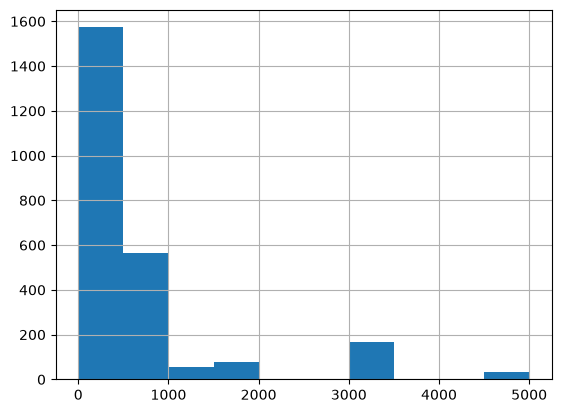

In [16]:
df_usd['budget_max'].hist(range=(0, 5000))

<Axes: >

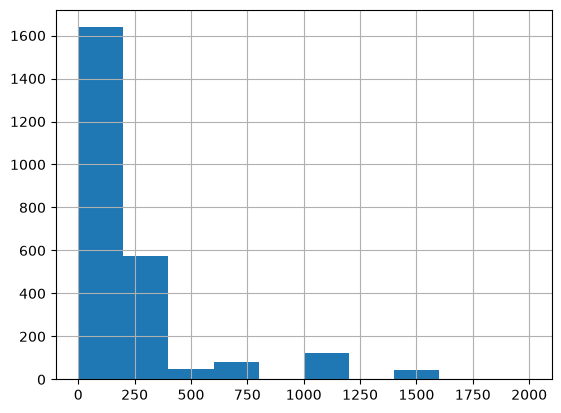

In [17]:
df_usd['budget_min'].hist(range=(0, 2000))

In [18]:
df_usd['budget_max'].describe()

count      2514.000000
mean       1062.054097
std        5938.090004
min           4.000000
25%          30.000000
50%         250.000000
75%         750.000000
max      150000.000000
Name: budget_max, dtype: float64

In [19]:
df_usd['max-min'] = df_usd['budget_max'] - df_usd['budget_min']

In [20]:
df_usd['max-min'].describe()

count     2488.000000
mean       622.796222
std       3257.014808
min          1.000000
25%         20.000000
50%        220.000000
75%        500.000000
max      90000.000000
Name: max-min, dtype: float64

In [21]:
df_usd.loc[df_usd['max-min'] == 90000]

,id,title,description,budget_min,budget_max,budget_type,skills,category,subcategory,project_url,platform,currency,created_at,max-min
1596,1557,Web Developer and Application Support,bout the Engagement\n\nSeeking a contractor wh...,60000.0,150000.0,fixed_price,"[Web Development, Website Management, Technica...","Websites, IT & Software",Web Development,https://www.freelancer.com/projects/web-develo...,Freelancer,USD,2026-07-25 07:37:02.107950,90000.0


In [22]:
df_usd['budget_type'].value_counts()

budget_type
fixed_price    1993
hourly          642
Name: count, dtype: int64

In [23]:
df_usd_fixed = df_usd[df_usd['budget_type'] == 'fixed_price'].copy()
df_usd_hourly = df_usd[df_usd['budget_type'] == 'hourly'].copy()

<Axes: >

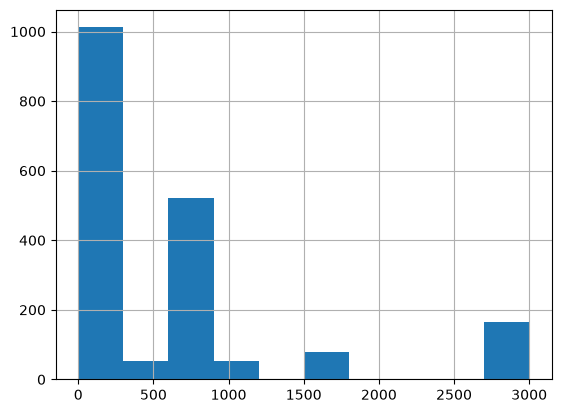

In [24]:
df_usd_fixed['budget_max'].hist(range=(0, 3000))

In [25]:
df_usd_fixed['budget_max'].describe()

count      1963.000000
mean       1353.609781
std        6691.438160
min          11.000000
25%         250.000000
50%         250.000000
75%         750.000000
max      150000.000000
Name: budget_max, dtype: float64

<Axes: >

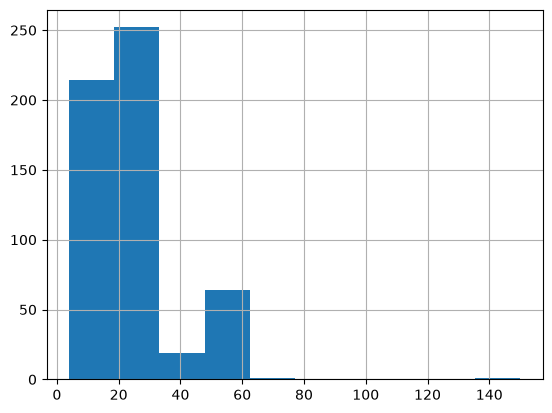

In [26]:
df_usd_hourly['budget_max'].hist()

In [27]:
df_usd_hourly['budget_max'].describe()

count    551.000000
mean      23.353902
std       14.192827
min        4.000000
25%       15.000000
50%       25.000000
75%       25.000000
max      150.000000
Name: budget_max, dtype: float64

In [28]:
print(round(((df_usd_fixed.loc[df_usd_fixed['budget_min'].isna()].shape[0]) / df_usd_fixed.shape[0] * 100), 2))
print(round(((df_usd_fixed.loc[df_usd_fixed['budget_max'].isna()].shape[0]) / df_usd_fixed.shape[0] * 100), 2))

0.65
1.51


In [29]:
print(round(((df_usd_hourly.loc[df_usd_hourly['budget_min'].isna()].shape[0]) / df_usd_hourly.shape[0] * 100), 2))
print(round(((df_usd_hourly.loc[df_usd_hourly['budget_max'].isna()].shape[0]) / df_usd_hourly.shape[0] * 100), 2))

2.02
14.17


**Aplicamos IQR para detectar outliers (fixed_price)**

In [30]:
Q1 = df_usd_fixed['budget_max'].quantile(0.25)
Q3 = df_usd_fixed['budget_max'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite inferior: {limite_inferior}, Límite superior: {limite_superior}")

outliers = df_usd_fixed.loc[(df_usd_fixed['budget_max'] < limite_inferior) | (df_usd_fixed['budget_max'] > limite_superior)]

print(f"Número de outliers: {outliers.shape[0]}")

Q1: 250.0, Q3: 750.0, IQR: 500.0
Límite inferior: -500.0, Límite superior: 1500.0
Número de outliers: 243


In [31]:
df_usd_fixed.loc[(df_usd_fixed['budget_max'] < limite_inferior) | (df_usd_fixed['budget_max'] > limite_superior), 'budget_max'].value_counts().sort_index()

budget_max
2000.0        2
3000.0      166
5000.0       35
6000.0        2
10000.0      20
20000.0       6
25000.0       1
30000.0       1
50000.0       4
100000.0      5
150000.0      1
Name: count, dtype: int64

**Aplicamos IQR para detectar outliers (hourly)**

In [32]:
Q1 = df_usd_hourly['budget_max'].quantile(0.25)
Q3 = df_usd_hourly['budget_max'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite inferior: {limite_inferior}, Límite superior: {limite_superior}")

outliers = df_usd_hourly.loc[(df_usd_hourly['budget_max'] < limite_inferior) | (df_usd_hourly['budget_max'] > limite_superior)]

print(f"Número de outliers: {outliers.shape[0]}")

Q1: 15.0, Q3: 25.0, IQR: 10.0
Límite inferior: 0.0, Límite superior: 40.0
Número de outliers: 83


In [33]:
df_usd_hourly.loc[(df_usd_hourly['budget_max'] < limite_inferior) | (df_usd_hourly['budget_max'] > limite_superior), 'budget_max'].value_counts().sort_index()

budget_max
45.0     17
50.0     63
60.0      1
70.0      1
150.0     1
Name: count, dtype: int64

## 3. Market Analysis

In [34]:
df['skills'].explode().value_counts()

skills
PHP                             931
Graphic Design                  915
HTML                            812
Web Development                 642
Website Design                  636
                               ... 
Automatic Speech Recognition      1
Seedance                          1
Machine Translation               1
Hebrew Translator                 1
Speech Synthesis                  1
Name: count, Length: 1542, dtype: int64

In [35]:
df['category'].value_counts()

category
Websites, IT & Software      4222
Programación y Tecnología     350
Artificial Intelligence       150
Name: count, dtype: int64

In [36]:
df['subcategory'].value_counts()

subcategory
Web Development                200
Programación Web               157
Adobe Premiere Pro             155
Adobe Illustrator              152
Web Design                     122
                              ... 
Music Production                 1
Comedy Writing                   1
Architectural Visualization      1
Machine Translation              1
Email Handling                   1
Name: count, Length: 679, dtype: int64

In [37]:
df.loc[(df['category'] == "Programación y Tecnología") | (df['category'] == "Artificial Intelligence"), 'platform'].value_counts()

platform
Workana       350
Freelancer    150
Name: count, dtype: int64

In [38]:
df.loc[df['category'] == "Websites, IT & Software", 'platform'].value_counts()

platform
Freelancer    4222
Name: count, dtype: int64

In [46]:
df.loc[df['platform'] == 'Freelancer', 'subcategory'].value_counts()

subcategory
Web Development                200
Adobe Premiere Pro             155
Adobe Illustrator              152
Web Design                     122
Social Media Management         81
                              ... 
Music Production                 1
Comedy Writing                   1
Architectural Visualization      1
Machine Translation              1
Email Handling                   1
Name: count, Length: 671, dtype: int64

In [43]:
df.loc[df['platform'] == 'Workana', 'subcategory'].value_counts()

subcategory
Programación Web                              157
Inteligencia Artificial                        50
Tiendas Online (e-commerce)                    47
Programación de Apps. Android, iOS y otros     40
Aplicaciones de escritorio                     19
Otros                                          16
Wordpress                                      10
Data Science                                    9
Diseño Web                                      2
Name: count, dtype: int64

In [47]:
df.head()

,id,title,description,budget_min,budget_max,budget_type,skills,category,subcategory,project_url,platform,currency,created_at
0,1,Implementador de Crm/Whatsapp Api con Automati...,Se busca un implementador freelance con experi...,250.0,500.0,fixed_price,"[CRM, API, Facebook, Scripts & Utilities, Data...",Programación y Tecnología,Tiendas Online (e-commerce),https://www.workana.com/job/implementador-de-c...,Workana,USD,2026-07-25 07:37:02.107950
1,2,"Automatización de Facturas con Ocr, Zapier e I...",Se busca un programador experto para diseñar e...,500.0,1000.0,fixed_price,"[SQL, Database, ERP, API, System Analysis, Mod...",Programación y Tecnología,Programación Web,https://www.workana.com/job/automatizacion-de-...,Workana,USD,2026-07-25 07:37:02.107950
2,3,Desarrollador Node.js / Sqlite para Proyecto C...,Buscamos un programador backend con perfil Jun...,100.0,250.0,fixed_price,"[Node.js, Express.js, SQL, Database, API]",Programación y Tecnología,Programación Web,https://www.workana.com/job/desarrollador-node...,Workana,USD,2026-07-25 07:37:02.107950
3,4,Desarrollador Wordpress + Elementor Pro para L...,Busco desarrollador con experiencia comprobabl...,100.0,250.0,fixed_price,"[WordPress, HTML, CSS, Responsive Web Design]",Programación y Tecnología,Programación Web,https://www.workana.com/job/desarrollador-word...,Workana,USD,2026-07-25 07:37:02.107950
4,5,Especialista Itil para Diseño e Implementación...,Actualmente me desempeño como Jefe de Servicio...,NaN,15.0,hourly,"[Informática, Technical Support, System Analys...",Programación y Tecnología,Otros,https://www.workana.com/job/especialista-itil-...,Workana,USD,2026-07-25 07:37:02.107950


In [58]:
print("Freelancer Fixed Price vs Hourly Percentage:")
print(round(((df.loc[(df['platform'] == 'Freelancer') & (df['budget_type'] == 'fixed_price')].shape[0] / df.loc[df['platform'] == 'Freelancer'].shape[0]) * 100), 2))
print(round(((df.loc[(df['platform'] == 'Freelancer') & (df['budget_type'] == 'hourly')].shape[0] / df.loc[df['platform'] == 'Freelancer'].shape[0]) * 100), 2))

Freelancer Fixed Price vs Hourly Percentage:
77.81
22.19


In [59]:
print("Workana Fixed Price vs Hourly Percentage:")
print(round(((df.loc[(df['platform'] == 'Workana') & (df['budget_type'] == 'fixed_price')].shape[0] / df.loc[df['platform'] == 'Workana'].shape[0]) * 100), 2))
print(round(((df.loc[(df['platform'] == 'Workana') & (df['budget_type'] == 'hourly')].shape[0] / df.loc[df['platform'] == 'Workana'].shape[0]) * 100), 2))

Workana Fixed Price vs Hourly Percentage:
87.43
12.57


## 4. Relationships Between Variables

### Budget vs Category